# Linear Regression from Scratch — NumPy Implementation

## What this notebook covers
1. ML basics — supervised learning, loss functions, why we optimize
2. Linear regression math — closed-form derivation
3. Matrix derivatives — ∂L/∂w, ∂L/∂b step by step
4. NumPy implementation — no sklearn

**Dataset:** Synthetic house sizes → prices (toy example)
**Goal:** Understand every line of code mathematically before using sklearn

## 1. Supervised learning
**Given a dataset of (input, output) pairs, find a function $f$ that maps new inputs to correct outputs.**
> **Dataset:** $\{(x⁽¹⁾, y⁽¹⁾), (x⁽²⁾, y⁽²⁾), ..., (x⁽ᵐ⁾, y⁽ᵐ⁾)\}$\
> **Goal:** learn $f$ such that $f(x) \approx y$ for unseen $x$
>
> $x$ = input features (house size, age, ...)
>
> $y$ = target / label (price, survived, ...)
>
> $m$ = number of training examples
----------------------------------------------------------------------------------------------------------------------
### Two types

<div style="display: flex; justify-content: space-between; gap: 20px;">
    <div style="flex: 1; padding: 15px; background-color: #f8f9fa; border-radius: 8px; border: 1px solid #dee2e6;">
        <b style="color: #495057;">Regression</b><br>
        $y$ is continuous<br>
        <small style="color: #6c757d;">e.g. house price = \$320k</small>
    </div>
    <div style="flex: 1; padding: 15px; background-color: #f8f9fa; border-radius: 8px; border: 1px solid #dee2e6;">
        <b style="color: #495057;">Classification</b><br>
        $y$ is discrete class<br>
        <small style="color: #6c757d;">e.g. survived = 0 or 1</small>
    </div>
</div>

--------------------------------------------------------------------------------------------------------------------

### vs unsupervised learning
**No labels — find hidden structure in data only (clustering, dimensionality reduction). Supervised = you tell the model the right answers during training. Unsupervised = no right answers given.**

> **Q: what is the difference between supervised and unsupervised learning?**
>
> *Supervised uses labelled (x, y) pairs to learn a mapping. Unsupervised uses only x to find structure. Example: predicting churn (supervised, label = churned/not); customer segmentation (unsupervised, group by behaviour with no predefined label).*

## 2. Hypothesis function h(x)
> The model's prediction for a given input x. Parameterized by θ (weights). For linear regression:

> $h_θ(x) = θ₀ + θ₁x₁ + θ₂x₂ + ... = θᵀx$
>
> $θ₀$ = bias / intercept (always present, $x₀$ = 1)
>
> $θ₁…$ = weights for each feature
>
> $θᵀx$ = dot product — single predicted number

**Learning = finding the θ values that make $h(x)$ as close to $y$ as possible across all training examples.**

> **Q: what does the bias term $θ₀$ do?**
>
> *It shifts the prediction line up or down, allowing the model to fit data that does not pass through the origin. Without $θ₀, h(x) = 0$ when all features = 0, which is rarely appropriate.*

## 3. Loss function J(θ)
**Measures how wrong the model is. We want to minimize J(θ) over all training examples.**

------------------------------------------------------------------------------------------------
**Mean Squared Error (MSE) — regression**
> $J(θ) = (1/2m) × Σᵢ (h_θ(x⁽ⁱ⁾) − y⁽ⁱ⁾)²$
>
> $(h − y)$ = error for one example (prediction − truth)\
> $(h − y)²$ = squared so negatives don't cancel positives\
> $1/2m$ = average over m examples; ½ for cleaner gradient math

-----------------------------
**Binary Cross-Entropy — classification**
> $J(θ) = −(1/m) × Σᵢ [ y⁽ⁱ⁾ log(ŷ⁽ⁱ⁾) + (1−y⁽ⁱ⁾) log(1−ŷ⁽ⁱ⁾) ]$
>
>Penalises confident wrong predictions very heavily (log → −∞)\
>When $y=1$: only −log(ŷ) matters → large penalty if ŷ near 0\
>When $y=0$: only −log(1−ŷ) matters → large penalty if ŷ near 1

>**Q: why squared error and not absolute error?**
>
> *MSE is differentiable everywhere (easy to compute gradients). MAE has a discontinuous gradient at 0. MSE also penalises large errors more, which is usually desirable. Downside: MSE is sensitive to outliers because it squares them.*

>**Q: why not use MSE for classification?**
>
> *With a sigmoid output, MSE creates a non-convex loss surface with many local minima — gradient descent gets stuck. Cross-entropy is convex for logistic regression, guaranteeing a single global minimum.*

## 4. Why we optimize — the learning objective

We want **θ\* = argmin J(θ)**. Two ways to find it:

| Method | Formula | When to use |
|---|---|---|
| Normal equation (closed-form) | θ = (XᵀX)⁻¹Xᵀy | Small n (≤10k features), fits in memory |
| Gradient descent (iterative) | θ = θ − α∇J(θ) | Large n, neural networks, non-convex |

### Gradient ∇J(θ) for MSE

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

>**In matrix form:**
$$\nabla J = \frac{1}{m} X^T(X\theta - y)$$

>**Update rule:**
$$\theta := \theta - \alpha \cdot \frac{1}{m} X^T(X\theta - y)$$

> **Q: when would you use the normal equation over gradient descent?**
>
> Normal equation when n (features) is small (≤ 10,000) and m fits in memory — gives exact answer, no tuning needed. Gradient descent when n is large (matrix inversion is O(n³)), or for non-linear models / neural networks where no closed form exists.

> **Q: what is the role of the learning rate α?**
>
> α controls the step size. Too large → overshoots minimum, loss diverges. Too small → converges very slowly. Typically tuned via learning rate schedules or adaptive optimizers (Adam).

## 5. Matrix derivative derivation — ∂J/∂θ step by step

Starting from J(θ) = (1/2m)||Xθ − y||²:

**Step 1:** expand the squared norm
J = (1/2m)(Xθ − y)ᵀ(Xθ − y)

**Step 2:** expand
J = (1/2m)(θᵀXᵀXθ − 2yᵀXθ + yᵀy)

**Step 3:** differentiate term by term
∂/∂θ (θᵀXᵀXθ) = 2XᵀXθ     ← using ∂(θᵀAθ)/∂θ = 2Aθ
∂/∂θ (2yᵀXθ)  = 2Xᵀy

**Step 4:** combine
∂J/∂θ = (1/2m)(2XᵀXθ − 2Xᵀy)
       = (1/m) Xᵀ(Xθ − y)    ✓  ← this is what we code in gradient()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# --- data (house sizes → prices) ---
X_raw = np.array([1, 2, 3, 4, 5], dtype=float) # m=5 examples
y = np.array([2, 4, 5, 4, 6], dtype=float)
m = len(y)
print("X_raw: ", X_raw)
print("y: ", y)
print("m: ", m)

X_raw:  [1. 2. 3. 4. 5.]
y:  [2. 4. 5. 4. 6.]
m:  5


In [3]:
# --- add bias column x₀=1 (intercept trick) ---
X = np.column_stack([np.ones(m), X_raw]) # shape (5, 2)
print("X", X)

X [[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]


In [4]:
# --- hypothesis ---
def h(X, theta): # h(x) = θᵀx
    # X: (m, n+1), theta: (n+1,) → returns (m,) predictions
    return X @ theta # (m,2)@(2,) → (m,)

In [5]:
# --- loss: MSE ---
def mse(X, y, theta):
    errors = h(X, theta) - y
    return (1/(2*m)) * np.dot(errors, errors)

In [6]:
# --- gradient ---
def gradient(X, y, theta):
    return (1/m) * X.T @ (h(X, theta) - y) # (2,)

In [7]:
# --- gradient descent ---
theta = np.zeros(2) # [θ₀, θ₁]
alpha = 0.1 # learning rate
losses = []
epochs = 500

for _ in range(epochs):
    theta = theta - alpha * gradient(X, y, theta)
    losses.append(mse(X, y, theta))
    
print(f"θ₀={theta[0]:.3f} θ₁={theta[1]:.3f}")
print(f"final loss: {losses[-1]:.4f}")

θ₀=1.800 θ₁=0.800
final loss: 0.2400


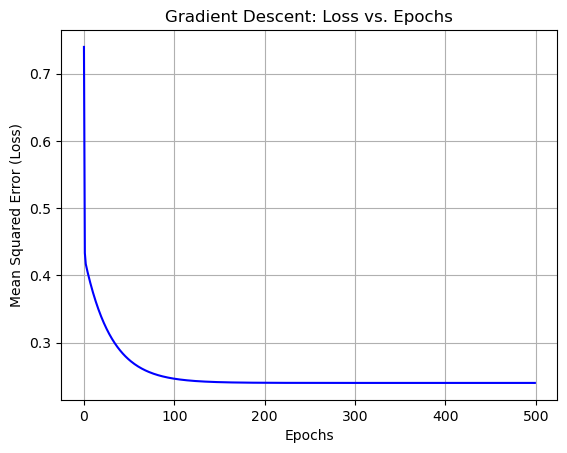

In [8]:
plt.plot(range(epochs), losses, color='blue')
plt.title("Gradient Descent: Loss vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.grid(True)
plt.show()

In [9]:
# Compare: closed-form normal equation
theta_ne, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
print(f"normal eq: θ₀={theta_ne[0]:.3f}  θ₁={theta_ne[1]:.3f}")
# theta_ne = np.linalg.inv(X.T @ X) @ X.T @ y
# print(f"normal eq: θ₀={theta_ne[0]:.3f} θ₁={theta_ne[1]:.3f}")

normal eq: θ₀=1.800  θ₁=0.800


> **Q: what is a loss function and why do we need it?** \
> It quantifies how wrong the model is on training data. Without a scalar objective, gradient descent has nothing to minimize. The choice of loss determines what the model optimises for — MSE for regression, cross-entropy for classification.

> **Q: what is the difference between loss, cost, and objective?** \
> Loss = error on one example. Cost = average loss over all m training examples (J(θ)). Objective = what we minimize, which is the cost function (sometimes with a regularisation term added).

> **Q: what happens when learning rate is too high / too low?** \
> Too high → gradient descent overshoots the minimum, loss oscillates or diverges. Too low → convergence is very slow, may get stuck in flat regions. In practice: start at 0.01, monitor loss curve, halve if diverging.

> **Q: does gradient descent always find the global minimum?** \
> For convex functions (MSE + linear regression) yes — only one minimum exists. For non-convex functions (neural networks) no — it finds a local minimum, but in practice many local minima generalize equally well.

> **Q: what is the bias-variance tradeoff?** \
>> Bias = error from wrong model assumptions (underfitting). \
>> Variance = error from sensitivity to training data fluctuations (overfitting). \
>> Simple models have high bias, low variance. Complex models have low bias, high variance. Regularization trades variance for bias to improve generalization.

> **Q: why do we split into train/val/test sets?** \
> Train = optimize θ. Val = tune hyperparameters (learning rate, model complexity) without touching test set. 
Test = final unbiased estimate of generalization error, used only once. Using test data for tuning causes data leakage — optimistically biased evaluation.

> **Q: what is overfitting and how do you detect it?** \
> Model memorizes training data but fails on unseen data. Sign: low training loss, high validation loss. Fix: more data, regularization (L1/L2), dropout, early stopping, simpler model.